# Example 7 — Power tracking RL setup (single-agent, derate-only)

*Example 6* showed that a hand-written proportional controller can follow a
power reference. The open question before training an RL agent is simpler and
more basic: **do we have a small, trustworthy tracking environment we can
inspect and poke at until we believe it behaves correctly?**

This notebook *builds and sanity-checks* exactly that env — it does **no RL
training**. The setup is deliberately minimal and fully deterministic:

- single-agent `WindFarmEnv`, a **3-turbine row at 6D** spacing, `backend="pywake"`,
- **fixed** inflow: `ws = 10 m/s`, `wd = 270°` (wakes the row inline), `TI = 6%`,
- **derate-only** actions (`yaw_action=False`, `derate_action=True`),
- a **step-wise** power reference cycling **80% → 60% → 70% → 100%** of the
  greedy waked farm power (100 steps per segment), the same trajectory every
  episode,
- observations = per-turbine **current value + value from exactly 2 steps ago**
  for wind speed, yaw and power; **no TI, no wind direction**, plus the
  farm-level tracking tail (setpoint + error).

Every setpoint sits **at or below** the greedy baseline on purpose. A
derate-only farm can essentially only *reduce* power: derating the upstream
turbine thins its wake and nudges downstream power up via axial induction, but
only by ~1% for this row (see the reachability map below), so a reference the
agent can actually reach must stay ≤ greedy. The **100%** segment is the
interesting edge — reachable only by holding every turbine at full power
(zero derate).


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from py_wake.examples.data.dtu10mw._dtu10mw import DTU10MW
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import DensityScale, PowerCtNDTabular

from WindGym import WindFarmEnv


## 1. Turbine — DTU 10MW derating surrogate

Reused verbatim from *Example 6*: a reduced power+ct surrogate of the DTU 10MW
that responds to a `derate` input. The `.nc` path is relative, so **run this
notebook from the `examples/` directory**.


In [2]:
# Reduced derating surrogate (power + ct) shipped with WindGym; see Example 5.
SURROGATE_NC = Path("data/dtu10mw_derating_yaw_surrogate.nc")
assert SURROGATE_NC.exists(), "run this notebook from the examples/ directory"


def make_derating_dtu10mw(nc_path=SURROGATE_NC) -> WindTurbine:
    ds = xr.load_dataset(nc_path).transpose("ws", "yaw", "derating")
    ref = DTU10MW()

    pctf = PowerCtNDTabular(
        input_keys=["ws", "yaw", "derate"],
        value_lst=[ds.ws.values, ds.yaw.values.astype(float), ds.derating.values],
        power_arr=ds.power.values,
        power_unit="W",
        ct_arr=ds.ct.values,
        default_value_dict={"yaw": 0.0, "derate": 0.0},
        additional_models=[DensityScale(1.225)],
    )
    for gi in pctf.interp:
        gi.bounds = "limit"

    return WindTurbine(
        name="DTU10MW",
        diameter=ref.diameter(),
        hub_height=ref.hub_height(),
        powerCtFunction=pctf,
    )


wt = make_derating_dtu10mw()
D = wt.diameter()
N_TURB = 3
print(f"D = {D:.1f} m, rated ~ {float(wt.power(12.0)) / 1e6:.1f} MW")


D = 178.3 m, rated ~ 10.0 MW


/tmp/ipykernel_250620/1177642724.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"D = {D:.1f} m, rated ~ {float(wt.power(12.0)) / 1e6:.1f} MW")


## 2. The derate-only tracking config

The config mirrors *Example 6* but is specialized for this test case. The
notable choices:

- **Geometry**: `x = [0, 6D, 12D]`, `y = 0` — a 6D row along the x-axis so
  `wd = 270°` (westerly) blows straight down the line, T1 → T2 → T3.
- **Fixed inflow**: ws/wd/TI ranges collapsed to single points.
- **Sensors** (`mes_level`): per-turbine wind speed and power on; per-turbine
  wind direction and TI off; **all farm-level sensors off**. The tracking tail
  already carries the farm-level setpoint and error, so per-turbine sensors +
  that tail are all the agent needs.
- **"current + 2-steps-ago" pattern** for `ws`, `power` and `yaw`
  (`current=False, rolling_mean=True, history_N=2, history_length=3,
  window_length=1`): a length-3 deque holds `[t-2, t-1, t]`, and the reducer
  returns `[value_now, value_{t-2}]` — the newest and the oldest entry.
- `wd_mes` is required by the schema but **off**; `derate_mes` is explicitly
  **off** so the obs is exactly the three sensors × {now, t-2} plus the tail.

Per-turbine block = `ws(2) + yaw(2) + power(2) = 6`; total obs =
`6 × 3 + 2 (setpoint, error) = 20`; action = `Box(-1, 1, (3,))`.


In [3]:
# "current + exactly-2-steps-ago" for a per-turbine sensor: a length-3 deque
# [t-2, t-1, t] with window_length=1 reduces to [value_now, value_t-2].
NOW_AND_T2 = dict(
    current=False,
    rolling_mean=True,
    history_N=2,
    history_length=3,
    window_length=1,
)


def make_config(**overrides):
    config = {
        "ActionMethod": "wind",
        "Track_power": True,
        "yaw_action": False,  # derate-only agent
        "derate_action": True,
        "derate_min": 0.0,
        "derate_max": 0.8,
        "derate_method": "absolute",
        "track_def": {
            "Track_reward": "abs",  # r = -|P_farm - P_ref| / (rated farm power)
            "track_obs_setpoint": True,
            "track_obs_error": True,
            "track_obs_preview": 0,
        },
        "farm": {"yaw_min": -30, "yaw_max": 30},
        "wind": {
            "ws_min": 10.0,
            "ws_max": 10.0,
            "TI_min": 0.06,
            "TI_max": 0.06,
            "wd_min": 270.0,
            "wd_max": 270.0,
        },
        "act_pen": {"action_penalty": 0.0, "action_penalty_type": "change"},
        # Track_power requires the power maximization reward to be off.
        "power_def": {"Power_reward": "None", "Power_avg": 5, "Power_scaling": 1.0},
        "mes_level": {
            "turb_ws": True,
            "turb_wd": False,
            "turb_TI": False,
            "turb_power": True,
            "farm_ws": False,
            "farm_wd": False,
            "farm_TI": False,
            "farm_power": False,
        },
        # Per-turbine sensors observed as [now, t-2].
        "ws_mes": {f"ws_{k}": v for k, v in NOW_AND_T2.items()},
        "power_mes": {f"power_{k}": v for k, v in NOW_AND_T2.items()},
        "yaw_mes": {f"yaw_{k}": v for k, v in NOW_AND_T2.items()},
        # wd sensor required by the schema but switched off.
        "wd_mes": {
            "wd_current": False,
            "wd_rolling_mean": False,
            "wd_history_N": 0,
            "wd_history_length": 3,
            "wd_window_length": 1,
        },
        # Derate sensor explicitly off. NOTE: the agent's own recent derate is
        # often a useful observation -- to add it, flip these to the NOW_AND_T2
        # pattern (`{f"derate_{k}": v for k, v in NOW_AND_T2.items()}`).
        "derate_mes": {"derate_current": False, "derate_rolling_mean": False},
    }
    config.update(overrides)
    return config


def make_env(config=None, **kwargs):
    kwargs.setdefault("max_time_steps", 400)  # 4 segments x 100 steps
    return WindFarmEnv(
        turbine=wt,
        x_pos=np.arange(N_TURB) * 6 * D,  # 6D row along x
        y_pos=np.zeros(N_TURB),
        config=config if config is not None else make_config(),
        backend="pywake",
        reset_init=False,
        **kwargs,
    )


## 3. Measure the greedy waked farm power

The step-wise reference is expressed as a fraction of the **greedy waked farm
power** — every turbine at full power (zero yaw, zero derate), *with* wakes.

Two facts make this a single constant we can measure once:

1. Conditions are fixed, so the greedy power never changes across the episode.
2. The reference trajectory is built *before* the flow is solved (`env.fs` is
   created after `reset_episode`), so the reference **cannot** read live waked
   power — it must close over a precomputed constant.

Right after `reset()` the turbines sit at zero yaw and zero derate, so
`env.fs.windTurbines.power().sum()` **is** the greedy waked farm power. We read
it from a throwaway probe env (its default reference sampler is irrelevant — we
only touch the flow state).


In [4]:
probe = make_env()  # default reference sampler is fine; we only read the flow
probe.reset(seed=0)
GREEDY = float(probe.fs.windTurbines.power().sum())
probe.close()

print(f"Greedy waked farm power (ws=10, wd=270, TI=6%): {GREEDY / 1e6:.3f} MW")
print(f"  per-turbine average:                          {GREEDY / N_TURB / 1e6:.3f} MW")


max_time_steps=400: episode length fixed to 400 env steps (400 s of simulation); n_passthrough is ignored.
Greedy waked farm power (ws=10, wd=270, TI=6%): 8.855 MW
  per-turbine average:                          2.952 MW


## 4. The step-wise reference

`power_ref_function(t_seconds, env) -> watts` is evaluated once per env step at
reset (step index `i` ↔ `t = i * env.delay` s), and the whole trajectory is
precomputed. It must be defined for any `t >= 0` — past the 400-step horizon it
simply holds the last fraction (the eval path may probe slightly beyond the
horizon).


In [5]:
# (n_steps, fraction of greedy) per segment; all <= 1.0 so derate-only can reach them.
SCHEDULE = [(100, 0.80), (100, 0.60), (100, 0.70), (100, 1.00)]


def stepwise_power_ref(t, env):
    step = int(round(t / env.delay))
    bounds = np.cumsum([n for n, _ in SCHEDULE])  # [100, 200, 300, 400]
    fracs = [f for _, f in SCHEDULE]
    idx = min(int(np.searchsorted(bounds, step, side="right")), len(fracs) - 1)
    return fracs[idx] * GREEDY  # holds the last fraction past the horizon


## 5. Build the tracking env and inspect the observation

Build the env with our step-wise reference, reset, and lay out the 20-length
observation vector explicitly so we can see every entry. The obs is scaled to
`[-1, 1]`; the human-readable magnitudes live in the info dict.


In [6]:
env = make_env(power_ref_function=stepwise_power_ref)
obs, info = env.reset(seed=0)

assert env.observation_space.shape == (20,), env.observation_space.shape
assert env.action_space.shape == (3,), env.action_space.shape

TRACK_KEYS = [
    "Power reference",
    "Tracking error",
    "Tracking error window mean",
    "Power reference preview",
]
for k in TRACK_KEYS:
    assert k in info, f"missing tracking info key: {k}"

print("observation_space.shape:", env.observation_space.shape)
print("action_space.shape:     ", env.action_space.shape, "(derate per turbine)\n")

# Labelled breakdown of the 20-length obs vector.
per_turb = ["ws_now", "ws_t-2", "yaw_now", "yaw_t-2", "power_now", "power_t-2"]
labels = [f"T{t + 1}:{name}" for t in range(N_TURB) for name in per_turb]
labels += ["setpoint", "error"]
assert len(labels) == 20

print("obs vector (scaled to [-1, 1]):")
for lab, val in zip(labels, obs):
    print(f"  {lab:<14} {val:+.4f}")

print("\ntracking info keys:")
for k in TRACK_KEYS:
    print(f"  {k:<28} {info[k]}")

print(f"\nGREEDY           = {GREEDY / 1e6:.3f} MW")
print(f"setpoint (step 0) = {info['Power reference'] / 1e6:.3f} MW"
      f"  (expected {0.80 * GREEDY / 1e6:.3f} MW = 80% of greedy)")


max_time_steps=400: episode length fixed to 400 env steps (400 s of simulation); n_passthrough is ignored.


observation_space.shape: (20,)
action_space.shape:      (3,) (derate per turbine)

obs vector (scaled to [-1, 1]):
  T1:ws_now      -0.3333
  T1:ws_t-2      -0.3333
  T1:yaw_now     +0.0000
  T1:yaw_t-2     +0.0000
  T1:power_now   +0.3386
  T1:power_t-2   +0.3386
  T2:ws_now      -0.6393
  T2:ws_t-2      -0.6393
  T2:yaw_now     +0.0000
  T2:yaw_t-2     +0.0000
  T2:power_now   -0.8070
  T2:power_t-2   -0.8070
  T3:ws_now      -0.6169
  T3:ws_t-2      -0.6169
  T3:yaw_now     +0.0000
  T3:yaw_t-2     +0.0000
  T3:power_now   -0.7606
  T3:power_t-2   -0.7606
  setpoint       -0.5277
  error          +0.0590

tracking info keys:
  Power reference              7083911.87659711
  Tracking error               1770978.0
  Tracking error window mean   1770978.1234028907
  Power reference preview      []

GREEDY           = 8.855 MW
setpoint (step 0) = 7.084 MW  (expected 7.084 MW = 80% of greedy)


### Confirm the step-wise reference and the step ↔ `env.delay` mapping

Stepping the env advances the reference by one trajectory index per step. We
apply the greedy action (all derate = 0, i.e. action = -1) and read
`info["Power reference"]` at the segment boundaries. The setpoint must be
`0.80·GREEDY` at step 0, `0.60·GREEDY` after 100 steps, `0.70·GREEDY` after
200 steps, and `1.00·GREEDY` after 300 steps.


In [7]:
env.reset(seed=0)
greedy_action = np.full(N_TURB, -1.0, dtype=np.float32)  # all derate = derate_min = 0

refs = {0: info["Power reference"]}  # step 0 (from the reset above's info)
for step in range(1, 301):
    _, _, _, _, info_s = env.step(greedy_action)
    if step in (100, 200, 300):
        refs[step] = info_s["Power reference"]

expected = {0: 0.80, 100: 0.60, 200: 0.70, 300: 1.00}
print("step |  setpoint [MW] | expected frac | frac of GREEDY")
for step in (0, 100, 200, 300):
    frac = refs[step] / GREEDY
    ok = np.isclose(frac, expected[step], atol=1e-6)
    print(f"{step:>4} | {refs[step] / 1e6:>12.3f} | {expected[step]:>13.2f} | "
          f"{frac:>8.3f}  {'OK' if ok else 'MISMATCH'}")
    assert ok, (step, frac, expected[step])
print("\nStep-wise reference and step<->env.delay mapping confirmed.")


step |  setpoint [MW] | expected frac | frac of GREEDY
   0 |        7.084 |          0.80 |    0.800  OK
 100 |        5.313 |          0.60 |    0.600  OK
 200 |        6.198 |          0.70 |    0.700  OK
 300 |        8.855 |          1.00 |    1.000  OK

Step-wise reference and step<->env.delay mapping confirmed.


## 6. Reachability sanity check — why the schedule stays at/below greedy

Pure derating only *reduces* a turbine's own power, so the 80 / 60 / 70%
targets (all below greedy) are trivially reachable and 100% is reachable by
holding full power. The natural follow-up — *could* a derate-only farm ever
**exceed** greedy? — is what this cell measures: derating the **upstream**
turbine (T1) thins its wake and lets T2/T3 see faster wind (axial-induction
control). The empirical answer sets the ceiling for how high a reachable
reference can go, which is why the schedule tops out at 100%.

`settled_farm_power` maps a per-turbine derate *setpoint* to an absolute action,
resets, and steps `n_settle` times to let the pywake wakes reach steady state
before reading farm power. A 6D row can need many steps to settle, so `n_settle`
is adjustable.


In [8]:
def settled_farm_power(env, derates, n_settle=150, seed=0):
    """Hold an absolute per-turbine derate for n_settle steps; return farm power [W]."""
    a = (2 * (np.asarray(derates) - env.derate_min)
         / (env.derate_max - env.derate_min) - 1).astype(np.float32)
    env.reset(seed=seed)
    for _ in range(n_settle):
        env.step(a)
    return float(env.fs.windTurbines.power().sum())


N_SETTLE = 150  # adjustable: pywake 6D row may need many steps to settle

# Baseline: all turbines greedy (derate 0) -> should recover ~GREEDY.
base = settled_farm_power(env, [0.0, 0.0, 0.0], n_settle=N_SETTLE)
print(f"all-greedy settled / GREEDY = {base / GREEDY:.4f}  (sanity: ~1.00)\n")

# Sweep the FRONT turbine derate (T2, T3 greedy) -- axial-induction control.
print("front-turbine derate sweep (T1 derated, T2/T3 greedy):")
print("   d0  | farm_power/GREEDY")
best_frac, best_cfg = -np.inf, None
for d0 in np.linspace(0.0, 0.8, 9):
    p = settled_farm_power(env, [d0, 0.0, 0.0], n_settle=N_SETTLE)
    frac = p / GREEDY
    print(f"  {d0:>4.2f} | {frac:>10.4f}")
    if frac > best_frac:
        best_frac, best_cfg = frac, (round(d0, 2), 0.0, 0.0)

# Small 2-D grid over the two upstream turbines.
print("\n2-D (d0, d1) grid, T3 greedy:")
for d0 in (0.0, 0.2, 0.4):
    row = []
    for d1 in (0.0, 0.2, 0.4):
        p = settled_farm_power(env, [d0, d1, 0.0], n_settle=N_SETTLE)
        frac = p / GREEDY
        row.append(f"{frac:.3f}")
        if frac > best_frac:
            best_frac, best_cfg = frac, (round(d0, 2), round(d1, 2), 0.0)
    print(f"  d0={d0:.1f}: " + "  ".join(f"d1={d1:.1f}->{v}"
                                         for d1, v in zip((0.0, 0.2, 0.4), row)))

print(f"\nmax reachable farm_power/GREEDY = {best_frac:.4f} at derates {best_cfg}")
print("\nReachability verdict:")
for target in (0.80, 0.60, 0.70, 1.00):
    verdict = "reachable" if best_frac >= target or target <= 1.0 else "NOT reachable"
    print(f"  {int(target * 100):>3}% of greedy: {verdict}")
print(
    "\n(All schedule targets are <= greedy, so all are reachable: 80/60/70% by\n"
    " derating the whole farm, 100% by holding full power. The max above shows\n"
    " how little derating can beat greedy (~1%), which is why the schedule does\n"
    " not ask for more than 100%.)"
)


all-greedy settled / GREEDY = 1.0000  (sanity: ~1.00)

front-turbine derate sweep (T1 derated, T2/T3 greedy):
   d0  | farm_power/GREEDY


  0.00 |     1.0000


  0.10 |     0.9957


  0.20 |     0.9986


  0.30 |     0.9948


...

  0.70 |     0.9344


  0.80 |     0.9111

2-D (d0, d1) grid, T3 greedy:


  d0=0.0: d1=0.0->1.000  d1=0.2->1.005  d1=0.4->1.009


  d0=0.2: d1=0.0->0.999  d1=0.2->1.002  d1=0.4->1.001


  d0=0.4: d1=0.0->0.984  d1=0.2->0.985  d1=0.4->0.975

max reachable farm_power/GREEDY = 1.0089 at derates (0.0, 0.4, 0.0)

Reachability verdict:
   80% of greedy: reachable
   60% of greedy: reachable
   70% of greedy: reachable
  100% of greedy: reachable

(All schedule targets are <= greedy, so all are reachable: 80/60/70% by
 derating the whole farm, 100% by holding full power. The max above shows
 how little derating can beat greedy (~1%), which is why the schedule does
 not ask for more than 100%.)


### Derate map — farm power over the (T1, T2) derate plane

A denser view of the same question: sweep the **front** turbine (T1) derate on
the x-axis against the **second** turbine (T2) derate on the y-axis, holding
**T3 at full power**, and colour each cell by farm power as a **% of greedy**.

The colour scale is *diverging about 100%* — the pivot is greedy itself, so
**red beats greedy, blue is below it**, and the bold contour is the 100%
break-even line. (The pywake backend is steady state — the settled power is
reached in a single step — so `n_settle=1` is exact here and the grid is cheap.)

The reachable-above-greedy region is a thin red sliver hugging the `T1 = 0`
edge (keep the big front producer at full power, derate T2 to unwake T3), and
it never gets far past 100% — the empirical justification for capping the
reference schedule at 100%.


max farm power = 101.00% of greedy at T1 derate=0.00, T2 derate=0.70


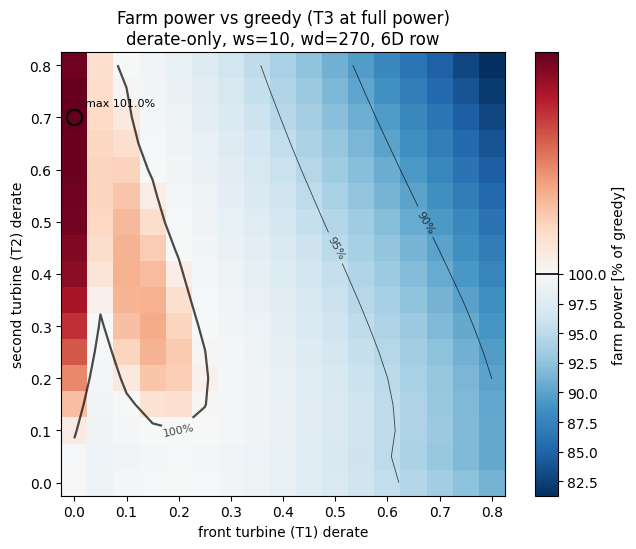

In [9]:
from matplotlib.colors import TwoSlopeNorm

grid = np.linspace(0.0, 0.8, 17)  # per-turbine derate setpoints to sweep
# rows = T2 derate (y), cols = T1 derate (x); T3 held at full power (derate 0).
P = np.array([[settled_farm_power(env, [d0, d1, 0.0], n_settle=1)
               for d0 in grid] for d1 in grid])
pct = 100.0 * P / GREEDY

imax = np.unravel_index(np.argmax(pct), pct.shape)
print(f"max farm power = {pct.max():.2f}% of greedy "
      f"at T1 derate={grid[imax[1]]:.2f}, T2 derate={grid[imax[0]]:.2f}")

fig, ax = plt.subplots(figsize=(7, 5.6))
# Diverging map pinned at 100% (= greedy): red beats greedy, blue is below it.
norm = TwoSlopeNorm(vmin=pct.min(), vcenter=100.0, vmax=max(pct.max(), 100.5))
step = grid[1] - grid[0]
edges = np.concatenate([grid - step / 2, [grid[-1] + step / 2]])
pcm = ax.pcolormesh(edges, edges, pct, cmap="RdBu_r", norm=norm, shading="flat")
cs = ax.contour(grid, grid, pct, levels=[90, 95, 100], colors="k",
                linewidths=[0.6, 0.6, 1.6], alpha=0.7)
ax.clabel(cs, fmt="%d%%", fontsize=8)
ax.plot(grid[imax[1]], grid[imax[0]], "o", mfc="none", mec="k", mew=1.5, ms=11)
ax.annotate(f"max {pct.max():.1f}%", (grid[imax[1]], grid[imax[0]]),
            textcoords="offset points", xytext=(8, 8), fontsize=8)
ax.set_xlabel("front turbine (T1) derate")
ax.set_ylabel("second turbine (T2) derate")
ax.set_title("Farm power vs greedy (T3 at full power)\n"
             "derate-only, ws=10, wd=270, 6D row")
ax.set_aspect("equal")
cb = fig.colorbar(pcm, ax=ax)
cb.set_label("farm power [% of greedy]")
cb.ax.axhline(100, color="k", lw=1.2)  # greedy break-even mark on the colour bar
plt.tight_layout()


## 7. Reference trajectory + greedy rollout (visual confirmation)

Finally, a light sanity plot (no training): roll out the full 400 steps with the
same proportional derate controller from *Example 6*, and overlay farm power on
the step-wise reference. We expect the setpoint to **step at 100 / 200 / 300**
and all four segments (**80 → 60 → 70 → 100%**) to be tracked — every target is
below or at greedy, so the derate-only controller can reach them all.


max_time_steps=400: episode length fixed to 400 env steps (400 s of simulation); n_passthrough is ignored.


mean farm power / GREEDY per (settled) segment:
   80%: 0.800
   60%: 0.600
   70%: 0.700
  100%: 1.000


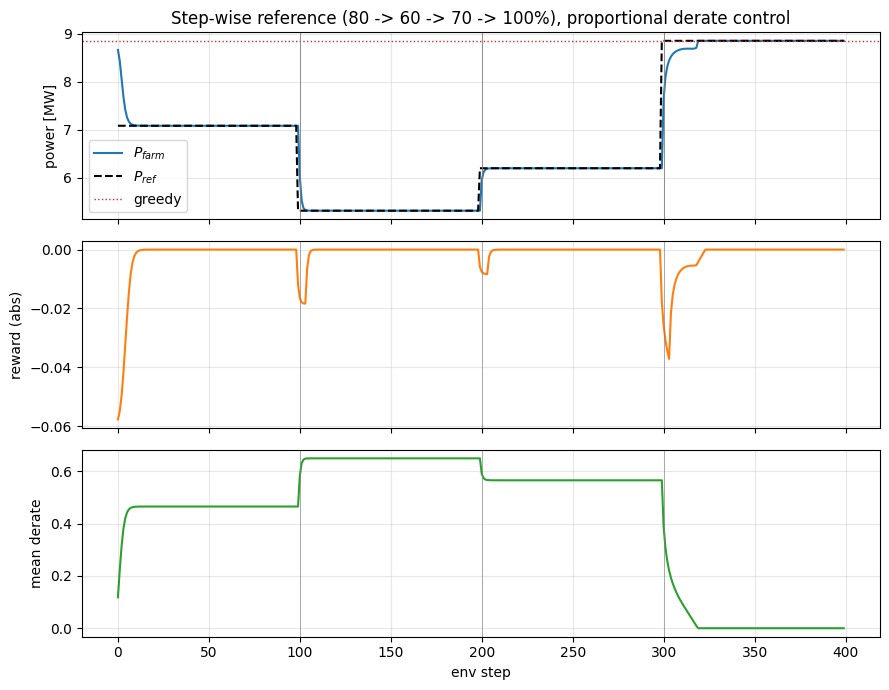

In [10]:
class DerateTrackingController:
    """Uniform proportional derate controller (not an RL agent), from Example 6."""

    def __init__(self, env, gain=2.0):
        self.env = env
        self.dmin, self.dmax = env.derate_min, env.derate_max
        self.p_norm = env.maxturbpower * env.n_turb
        self.gain = gain
        self.derate = 0.0

    def act(self, info):
        err = info["Tracking error"]  # P_farm - P_ref [W]
        self.derate = float(
            np.clip(self.derate + self.gain * err / self.p_norm, self.dmin, self.dmax)
        )
        action = 2 * (self.derate - self.dmin) / (self.dmax - self.dmin) - 1
        return np.full(self.env.n_turb, action, dtype=np.float32)


def rollout(env, seed=0, n_steps=400):
    _, info = env.reset(seed=seed)
    ctrl = DerateTrackingController(env)
    log = {"p_farm": [], "p_ref": [], "reward": [], "derate": []}
    for _ in range(n_steps):
        _, reward, _, truncated, info = env.step(ctrl.act(info))
        log["p_farm"].append(info["Power agent"])
        log["p_ref"].append(info["Power reference"])
        log["reward"].append(reward)
        log["derate"].append(info["derate agent"].mean())
        if truncated:
            break
    return {k: np.asarray(v) for k, v in log.items()}


log = rollout(make_env(power_ref_function=stepwise_power_ref), seed=0)

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(log["p_farm"] / 1e6, label="$P_{farm}$")
axes[0].plot(log["p_ref"] / 1e6, "k--", label="$P_{ref}$")
axes[0].axhline(GREEDY / 1e6, color="tab:red", ls=":", lw=1, label="greedy")
for b in (100, 200, 300):
    axes[0].axvline(b, color="gray", lw=0.7, alpha=0.6)
axes[0].set_ylabel("power [MW]")
axes[0].set_title("Step-wise reference (80 -> 60 -> 70 -> 100%), proportional derate control")
axes[0].legend(loc="best")
axes[1].plot(log["reward"], color="tab:orange")
axes[1].set_ylabel("reward (abs)")
axes[2].plot(log["derate"], color="tab:green")
axes[2].set_ylabel("mean derate")
axes[2].set_xlabel("env step")
for ax in axes:
    ax.grid(alpha=0.3)
    for b in (100, 200, 300):
        ax.axvline(b, color="gray", lw=0.7, alpha=0.6)
plt.tight_layout()

seg = {
    "80%": log["p_farm"][50:100],
    "60%": log["p_farm"][150:200],
    "70%": log["p_farm"][250:300],
    "100%": log["p_farm"][350:400],
}
print("mean farm power / GREEDY per (settled) segment:")
for name, arr in seg.items():
    print(f"  {name:>4}: {arr.mean() / GREEDY:.3f}")
